# import libaries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

In [9]:
df = pd.read_csv("data/loan.csv")

df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [10]:
df.head(10)

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
5,148,Male,Yes,1,Graduate,No,1538,1425.0,30,360,1,Urban,Y
6,271,Female,No,0,Graduate,No,3237,0.0,30,360,1,Urban,Y
7,29,Male,No,0,Not Graduate,No,1442,0.0,35,360,1,Urban,N
8,583,Female,Yes,0,Graduate,No,3166,0.0,36,360,1,Semiurban,Y
9,510,Female,No,1,Graduate,No,13262,0.0,40,360,1,Urban,Y


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    str    
 2   Married             614 non-null    str    
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    str    
 5   Self_Employed       614 non-null    str    
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    str    
 12  Loan_Status         614 non-null    str    
dtypes: float64(1), int64(6), str(6)
memory usage: 62.5 KB


In [12]:
df.head(10)

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
5,148,Male,Yes,1,Graduate,No,1538,1425.0,30,360,1,Urban,Y
6,271,Female,No,0,Graduate,No,3237,0.0,30,360,1,Urban,Y
7,29,Male,No,0,Not Graduate,No,1442,0.0,35,360,1,Urban,N
8,583,Female,Yes,0,Graduate,No,3166,0.0,36,360,1,Semiurban,Y
9,510,Female,No,1,Graduate,No,13262,0.0,40,360,1,Urban,Y


In [13]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 614
Columns : 13


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
df = df.ffill()

df.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [15]:
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


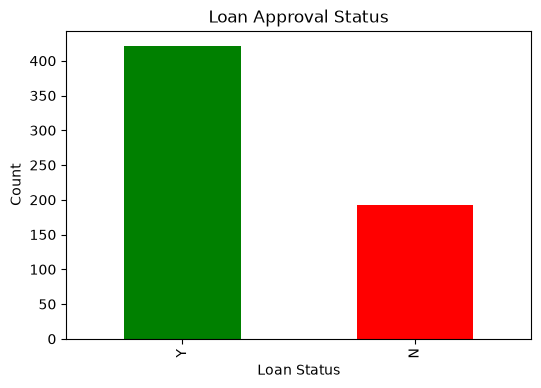

In [16]:
plt.figure(figsize=(6,4))

df["Loan_Status"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

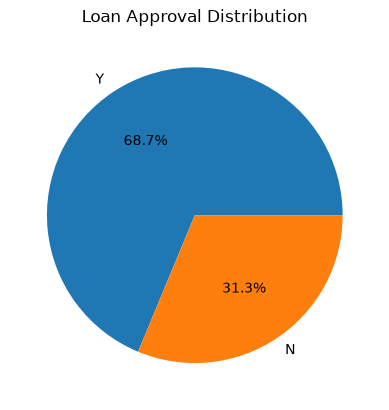

In [19]:
df["Loan_Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Loan Approval Distribution")
plt.ylabel("")
plt.show()

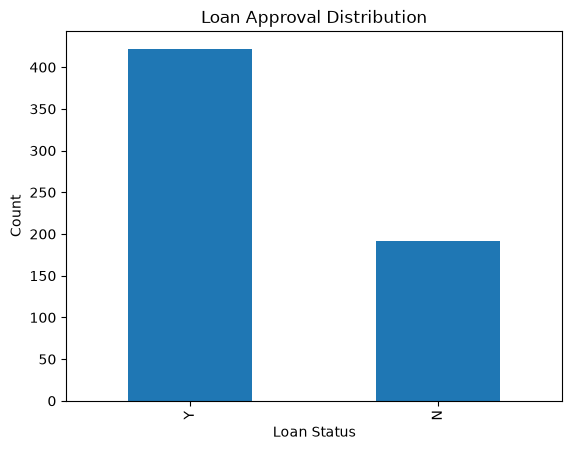

In [20]:
df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

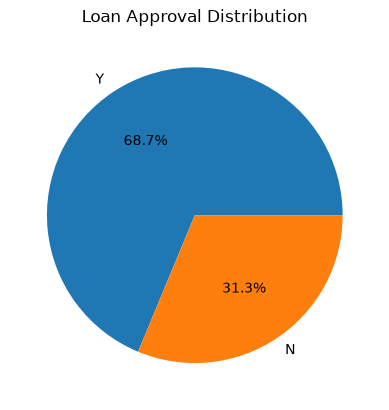

In [22]:
df["Loan_Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Loan Approval Distribution")
plt.ylabel("")
plt.show()

In [23]:
if "Loan_ID" in df.columns:
    df = df.drop("Loan_ID", axis=1)

df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [24]:
import pandas as pd

df = pd.read_csv("data/loan.csv")
print(df.head())

   Customer_ID  Gender Married  Dependents     Education Self_Employed  \
0          569  Female      No           0      Graduate            No   
1           15    Male     Yes           2      Graduate            No   
2           95    Male      No           0  Not Graduate            No   
3          134    Male     Yes           0      Graduate           Yes   
4          556    Male     Yes           1      Graduate            No   

   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Amount_Term  \
0              2378                 0.0            9               360   
1              1299              1086.0           17               120   
2              3620                 0.0           25               120   
3              3459                 0.0           25               120   
4              5468              1032.0           26               360   

   Credit_History Property_Area Loan_Status  
0               1         Urban           N  
1               1 

In [25]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print(X.head())
print(y.head())


   Customer_ID  Gender Married  Dependents     Education Self_Employed  \
0          569  Female      No           0      Graduate            No   
1           15    Male     Yes           2      Graduate            No   
2           95    Male      No           0  Not Graduate            No   
3          134    Male     Yes           0      Graduate           Yes   
4          556    Male     Yes           1      Graduate            No   

   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Amount_Term  \
0              2378                 0.0            9               360   
1              1299              1086.0           17               120   
2              3620                 0.0           25               120   
3              3459                 0.0           25               120   
4              5468              1032.0           26               360   

   Credit_History Property_Area  
0               1         Urban  
1               1         Urban  
2       

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(491, 12)
(123, 12)


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)

Customer_ID             int64
Gender                  int64
Married                 int64
Dependents              int64
Education               int64
Self_Employed           int64
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area           int64
Loan_Status             int64
dtype: object


In [35]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


c:\Users\vishn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
print(X_train.dtypes)

Customer_ID             int64
Gender                    str
Married                   str
Dependents              int64
Education                 str
Self_Employed             str
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area             str
dtype: object


In [30]:
print(X_train.head())

     Customer_ID  Gender Married  Dependents     Education Self_Employed  \
83           427  Female      No           1  Not Graduate            No   
90           479    Male     Yes           1      Graduate           Yes   
227           20    Male     Yes           0      Graduate            No   
482          519    Male      No           0      Graduate            No   
464          415  Female     Yes           0  Not Graduate            No   

     Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Amount_Term  \
83               4606                 0.0           81               360   
90              16667              2250.0           86               360   
227              2600              3500.0          115               120   
482              4683              1915.0          185               360   
464              2149              3237.0          178               360   

     Credit_History Property_Area  
83                1         Rural  
90            

In [31]:
df.dtypes

Customer_ID             int64
Gender                    str
Married                   str
Dependents              int64
Education                 str
Self_Employed             str
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area             str
Loan_Status               str
dtype: object

In [ ]:
if "Loan_ID" in df.columns:
    df = df.drop("Loan_ID", axis=1)

df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [38]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8211382113821138


In [40]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/loan_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
print(df.columns.tolist())


['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [42]:
loaded_model = joblib.load("models/loan_model.pkl")

sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Loan Approved


In [43]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/loan_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
